In [ ]:
import pandas as pd
df = pd.read_csv("Receiving2024Season.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df = df[df['Rec']>20]
df.drop_duplicates(subset='Player', keep='first', inplace=True)
df.head()

,Player,Age,Pos,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,BrkTkl,Succ.,TD,YBC_R,YAC_R,Rec_Brk
0,Ja'Marr Chase,24,WR,175,127,1708,75,921,787,8.7,11,62.3,17,7.3,6.2,11.5
1,Amon-Ra St. Brown,25,WR,141,115,1263,73,851,412,7.7,3,70.2,12,7.4,3.6,38.3
2,Brock Bowers,22,TE,153,112,1194,61,598,596,6.1,6,60.8,5,5.3,5.3,18.7
3,Trey McBride,25,TE,147,111,1146,63,633,513,6.1,5,63.3,2,5.7,4.6,22.2
4,Malik Nabers,21,WR,170,109,1204,55,742,462,9.1,8,51.2,7,6.8,4.2,13.6


In [ ]:
# Missing Values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Player     0
Age        0
Pos        0
Tgt        0
Rec        0
Yds        0
X1D        0
YBC        0
YAC        0
ADOT       0
BrkTkl     0
Succ.      0
TD         0
YBC_R      0
YAC_R      0
Rec_Brk    0
dtype: int64


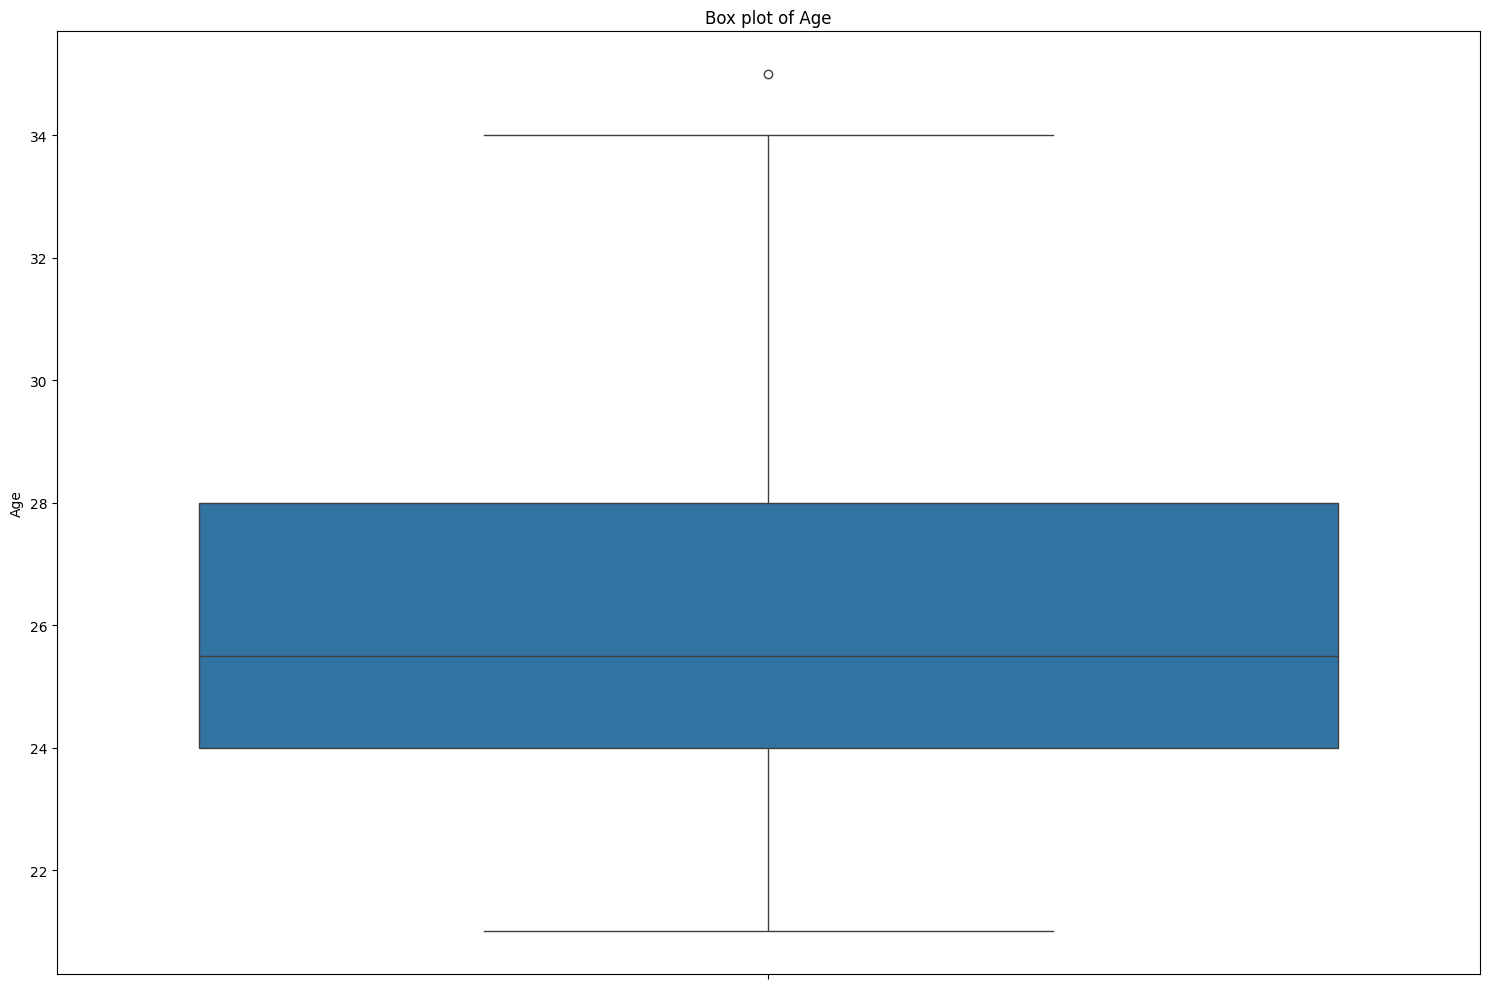

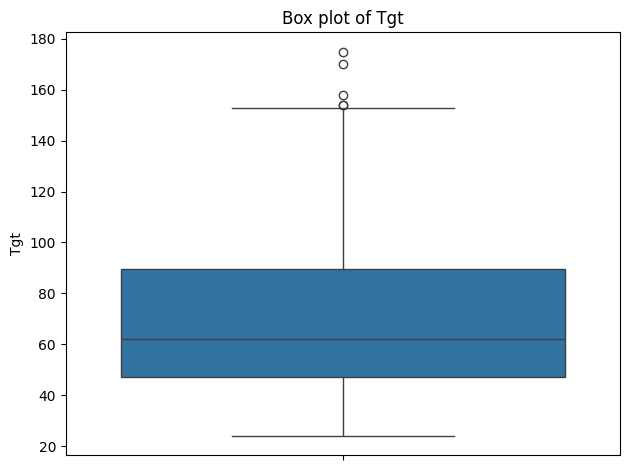

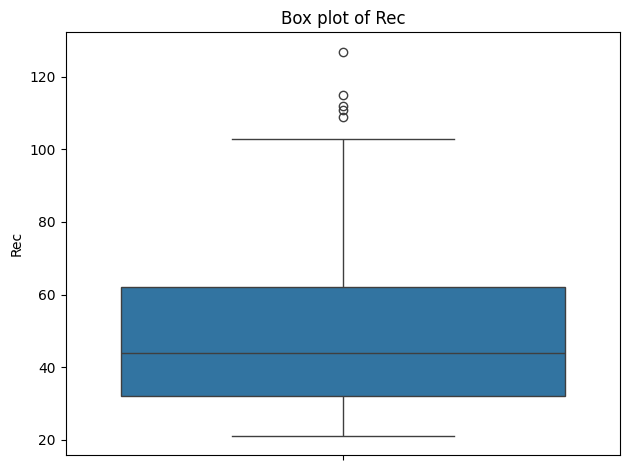

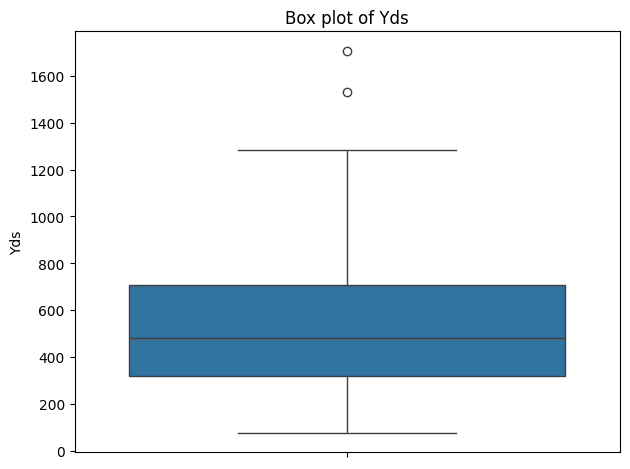

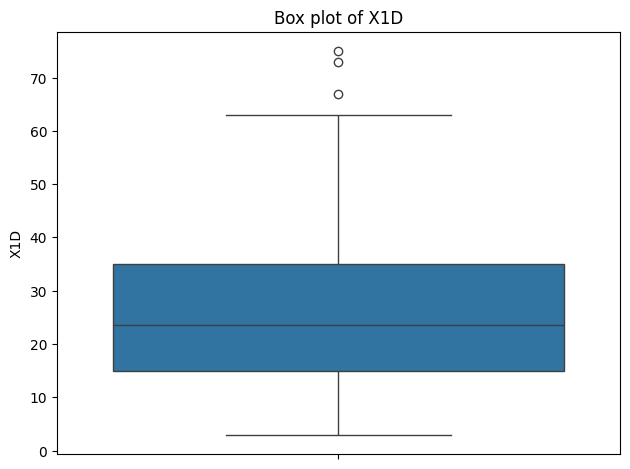

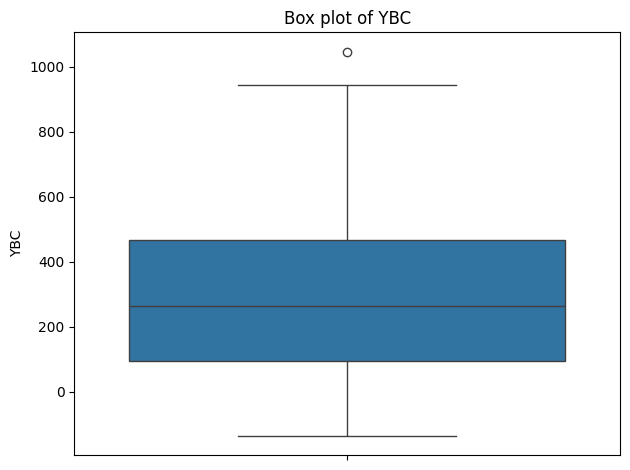

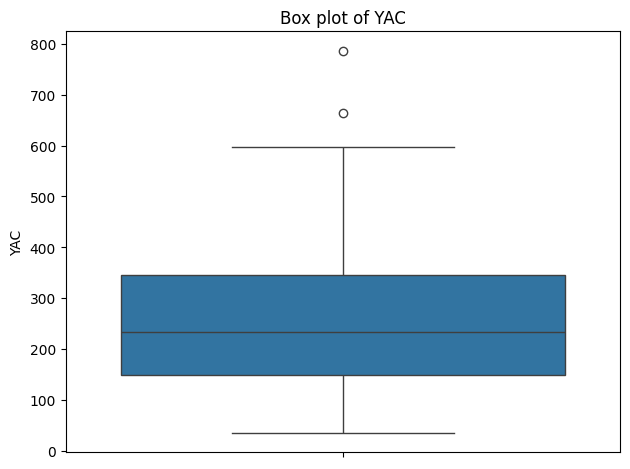

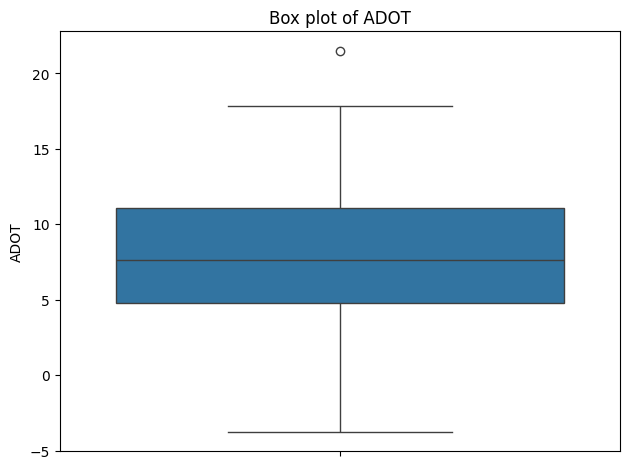

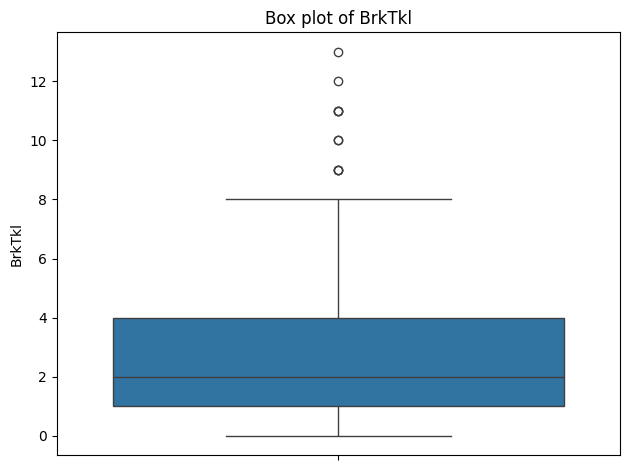

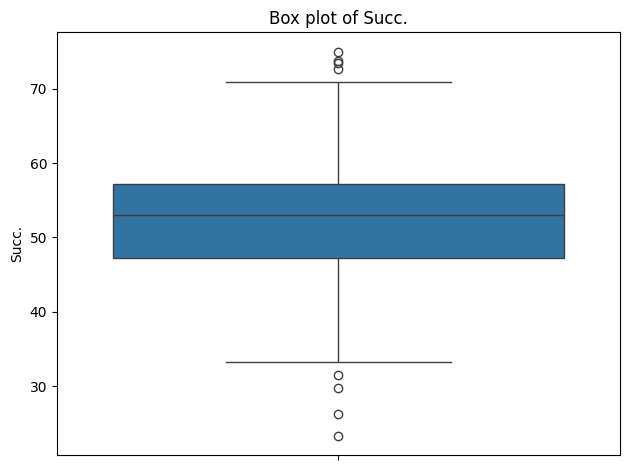

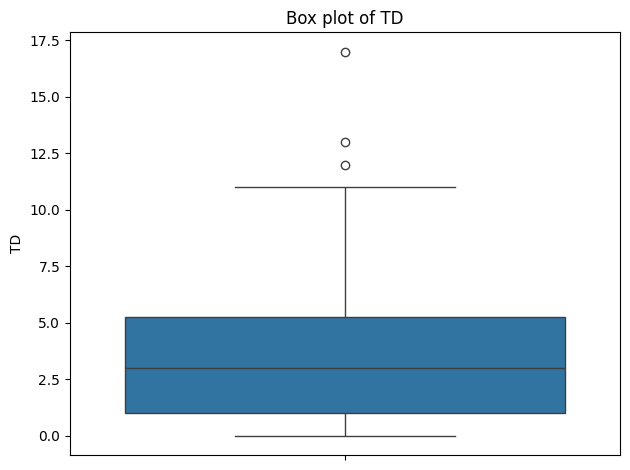

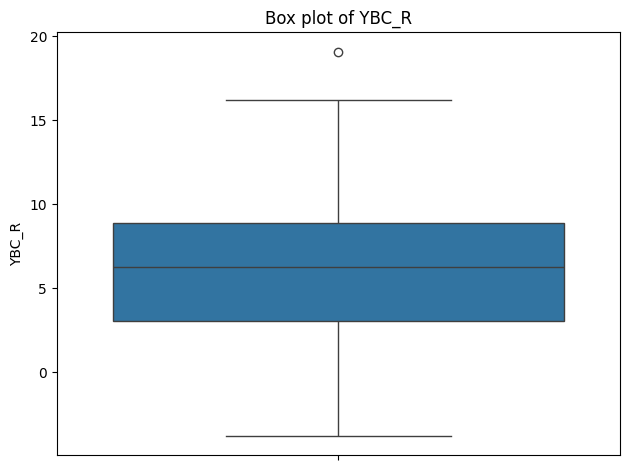

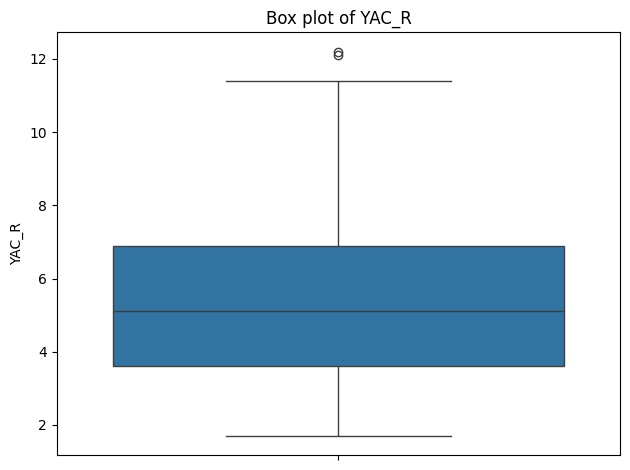

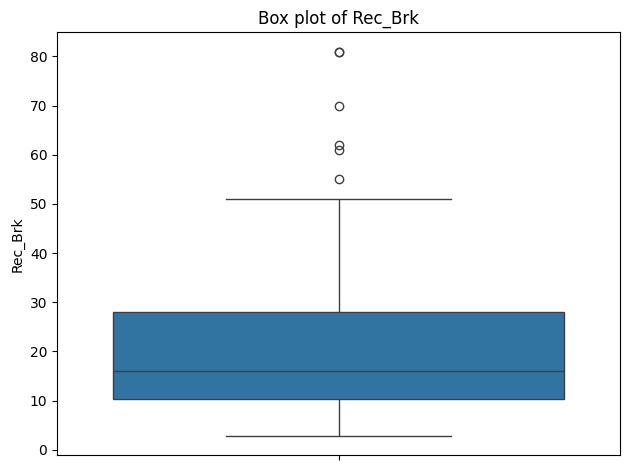

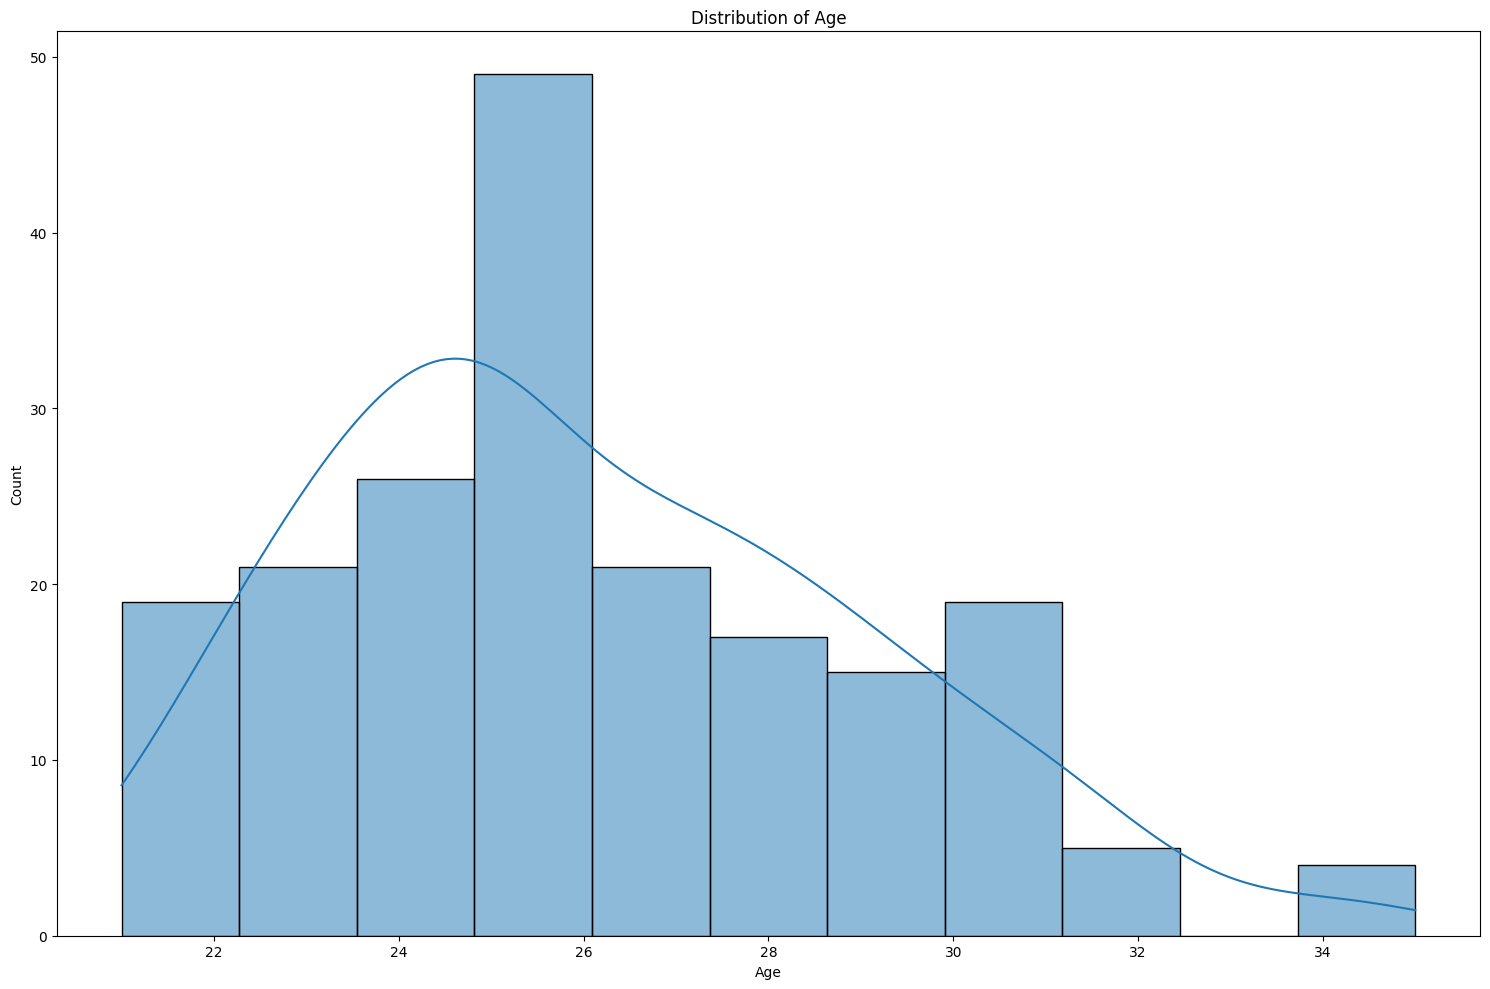

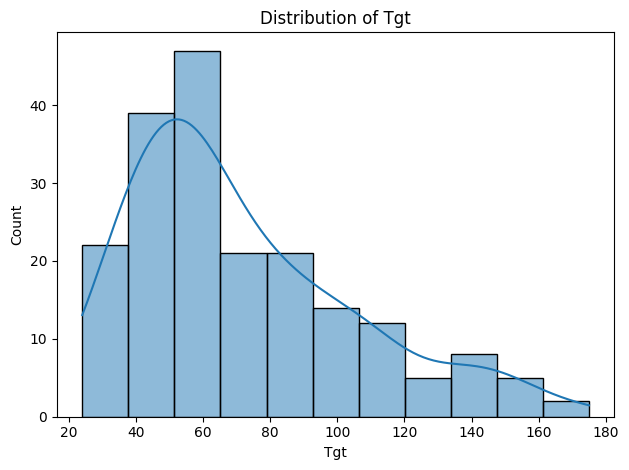

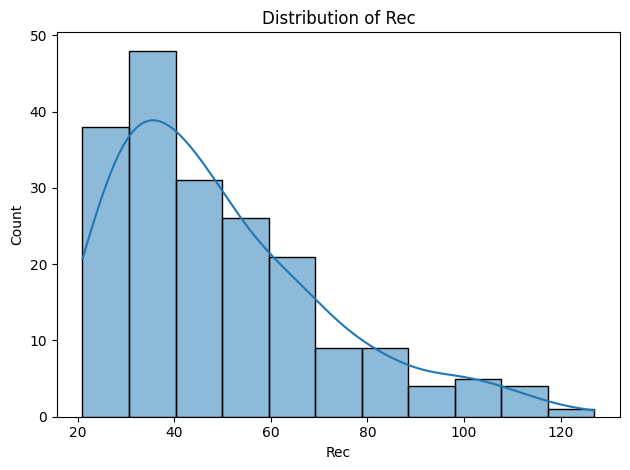

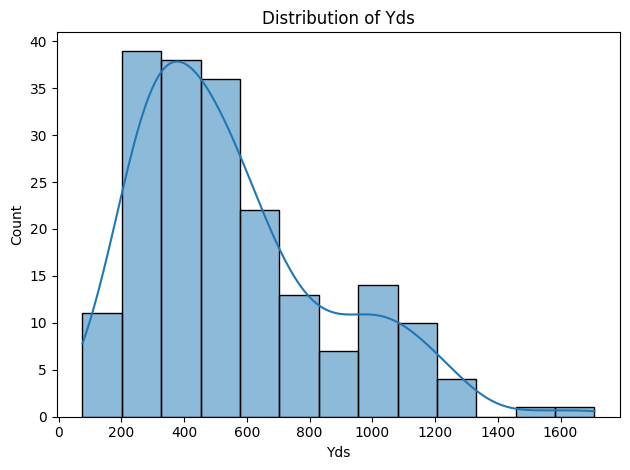

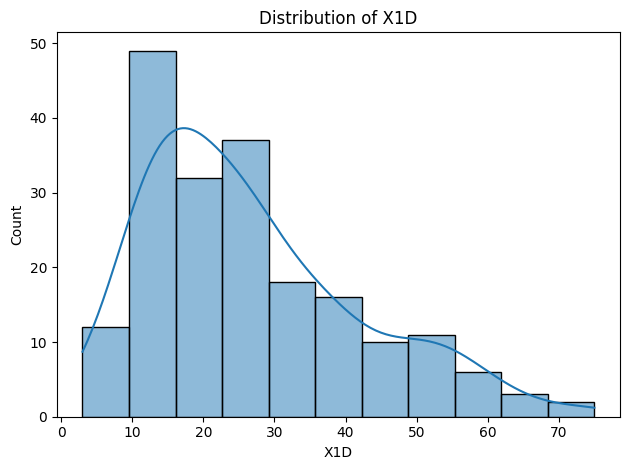

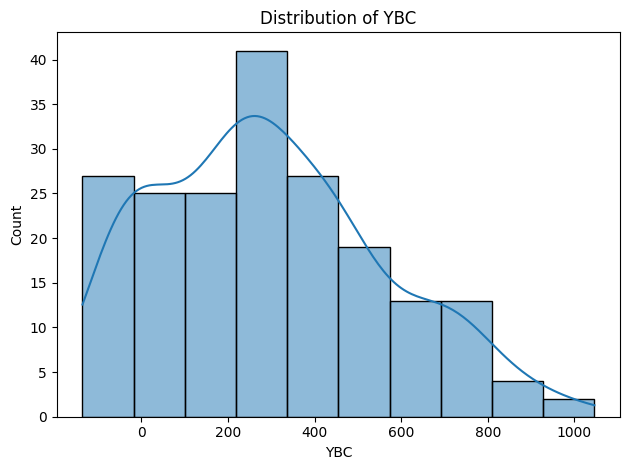

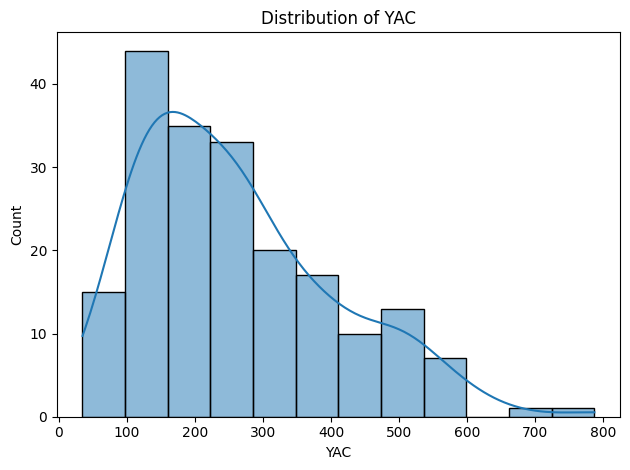

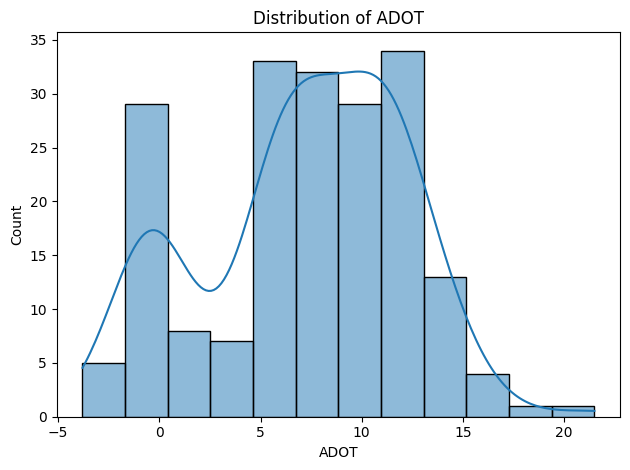

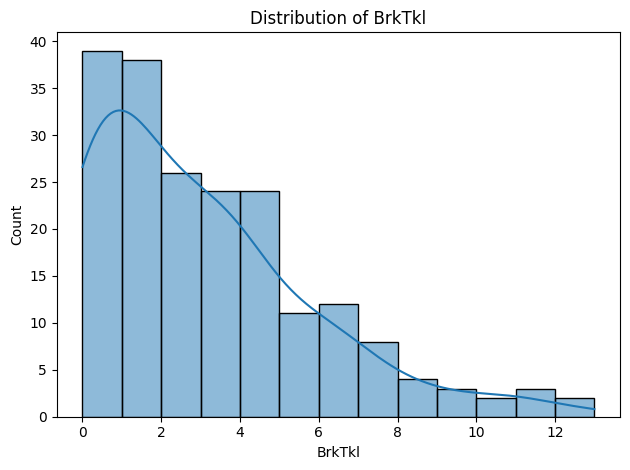

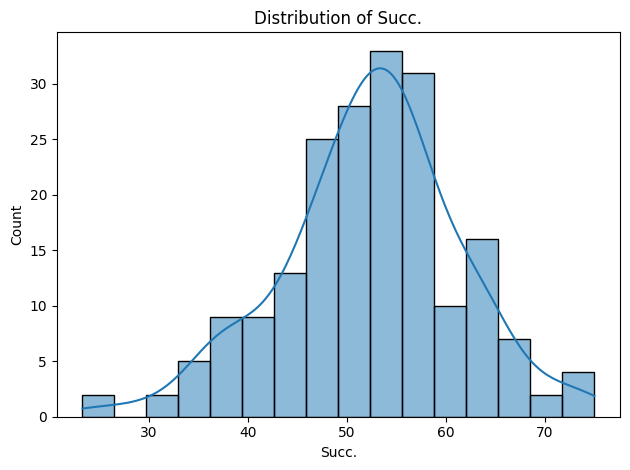

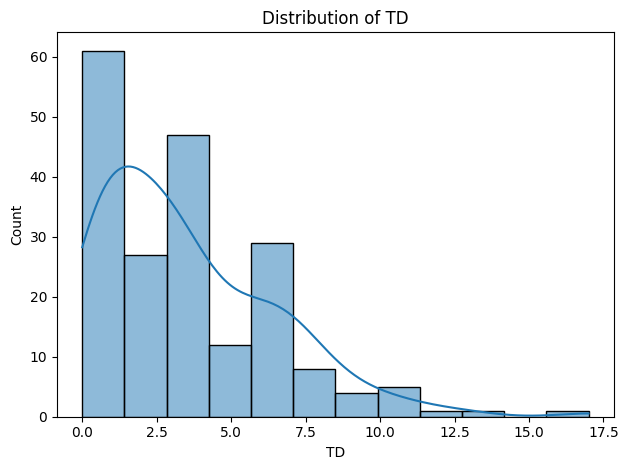

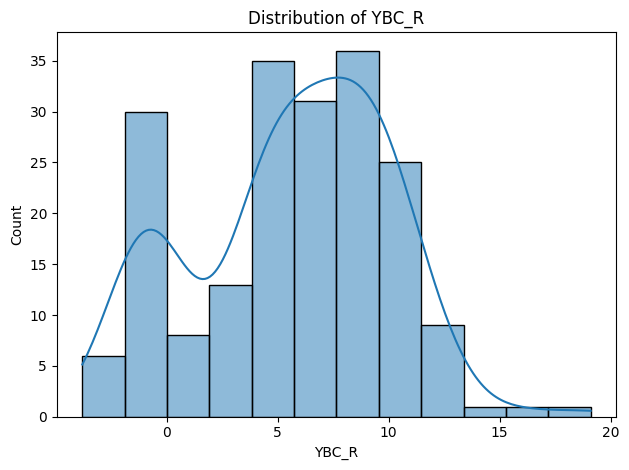

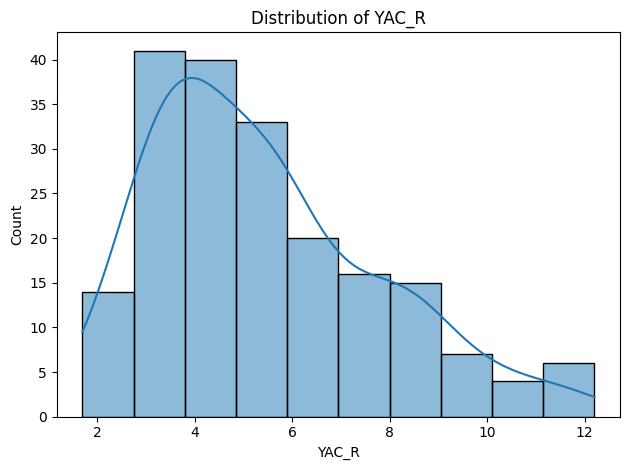

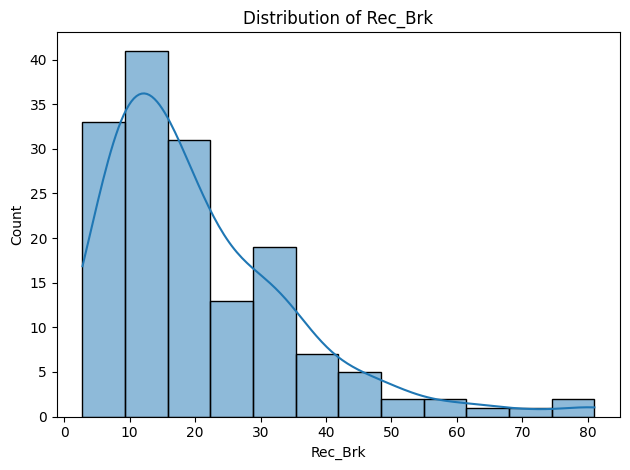

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = df.columns.tolist()
features.remove("Player")
features.remove("Pos")
# Potential Outliers (Box plots and Histograms)

# Calculate the number of rows and columns for subplots
num_features = len(features)
num_cols = 2  # Number of columns
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


Correlation Matrix:


,Age,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,BrkTkl,Succ.,TD,YBC_R,YAC_R,Rec_Brk
Age,1.000000,-0.053053,-0.044463,-0.066379,0.001265,0.036771,-0.209041,0.005509,-0.155030,0.097558,-0.033582,0.069765,-0.200918,0.275702
Tgt,-0.053053,1.000000,0.957567,0.925122,0.916048,0.788156,0.539275,0.332081,0.348854,0.102890,0.642553,0.336158,-0.284219,0.179889
Rec,-0.044463,0.957567,1.000000,0.895653,0.896304,0.676996,0.679178,0.137253,0.419515,0.204803,0.622193,0.160087,-0.141278,0.133784
Yds,-0.066379,0.925122,0.895653,1.000000,0.960004,0.884409,0.523670,0.456368,0.315973,0.298986,0.740882,0.487619,-0.252581,0.149710
X1D,0.001265,0.916048,0.896304,0.960004,1.000000,0.878731,0.448522,0.448567,0.276885,0.385945,0.746384,0.485782,-0.338809,0.209788
YBC,0.036771,0.788156,0.676996,0.884409,0.878731,1.000000,0.065537,0.746910,0.033419,0.293037,0.698471,0.788742,-0.617161,0.311562
YAC,-0.209041,0.539275,0.679178,0.523670,0.448522,0.065537,1.000000,-0.387651,0.614561,0.104345,0.309071,-0.397194,0.586516,-0.266060
ADOT,0.005509,0.332081,0.137253,0.456368,0.448567,0.746910,-0.387651,1.000000,-0.305741,0.162868,0.424052,0.962998,-0.737543,0.344345
BrkTkl,-0.155030,0.348854,0.419515,0.315973,0.276885,0.033419,0.614561,-0.305741,1.000000,0.018751,0.130286,-0.294157,0.400969,-0.636937
Succ.,0.097558,0.102890,0.204803,0.298986,0.385945,0.293037,0.104345,0.162868,0.018751,1.000000,0.320179,0.252158,-0.072018,0.057877


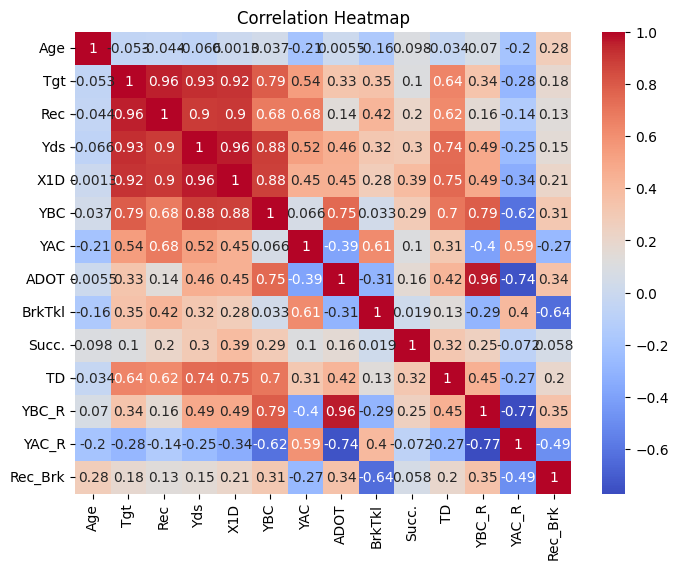

In [ ]:
correlation_matrix = df[features].corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
!pip install statsmodels
import statsmodels.api as sm
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset
df = pd.read_csv("Receiving2024Season.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df = df[df['Rec'] > 20]
df.drop_duplicates(subset='Player', keep='first', inplace=True)

# Define your target variable (is_WR in this example)
df['is_WR'] = (df['Pos'] == 'WR').astype(int)

# Select features (X) and target (y)
X = df[['YBC_R', 'YAC_R']]
y = df['is_WR']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Add a constant to the independent variables (for the intercept term)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Create and fit the logistic regression model
model = sm.Logit(y_train, X_train)
result = model.fit(maxiter=1000)  # Increase maxiter if needed

# Print model summary
print(result.summary())

# Make predictions on the test set
y_pred_prob = result.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels (0 or 1)

# Evaluate the model
accuracy = (y_pred == y_test).mean()  # Using .mean() for accuracy calculation
print("Accuracy on test set:", accuracy)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (Gradient): {mse}")
print(f"R-squared (Gradient): {r2}")

Optimization terminated successfully.
         Current function value: 0.392675
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  is_WR   No. Observations:                  147
Model:                          Logit   Df Residuals:                      144
Method:                           MLE   Df Model:                            2
Date:                Fri, 02 May 2025   Pseudo R-squ.:                  0.4280
Time:                        14:47:53   Log-Likelihood:                -57.723
converged:                       True   LL-Null:                       -100.91
Covariance Type:            nonrobust   LLR p-value:                 1.759e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7397      1.493     -3.174      0.002      -7.667      -1.813
YBC_R          0.6471      0.

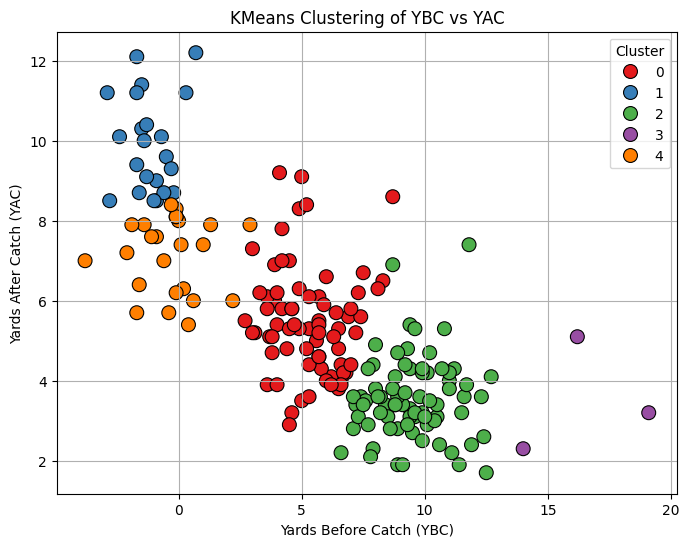

cluster
2    75
0    72
4    24
1    22
3     3
Name: count, dtype: int64
         YBC_R  YAC_R
cluster              
0         5.32   5.49
1        -1.18   9.92
2         9.49   3.56
3        16.43   3.53
4        -0.31   7.14


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import sklearn as sk
import numpy as np
import  matplotlib.pyplot as plt

km = KMeans(n_clusters=5)
predicted = km.fit_predict(df[['YBC_R', 'YAC_R']])
km.cluster_centers_
df['cluster'] = predicted
df.head()

# Create a scatter plot with different colors for each cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='YBC_R',
    y='YAC_R',
    hue='cluster',        # color by cluster
    palette='Set1',       # or 'Set2', 'Set3', etc.
    s=100,                # size of points
    edgecolor='k'         # black border
)
plt.title('KMeans Clustering of YBC vs YAC')
plt.xlabel('Yards Before Catch (YBC)')
plt.ylabel('Yards After Catch (YAC)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

count_by_cluster = df['cluster'].value_counts()
print(count_by_cluster)

cluster_means = round(df.groupby('cluster')[['YBC_R', 'YAC_R']].mean(), 2)
print(cluster_means)

cluster0 = df[df['cluster'] == 0]
cluster1 = df[df['cluster'] == 1]
cluster2 = df[df['cluster'] == 2]
cluster3 = df[df['cluster'] == 3]
cluster4 = df[df['cluster'] == 4]

In [ ]:
# Reorder players within each cluster's DataFrame
cluster0_sorted = cluster0.sort_values(by='YAC_R', ascending=False)
cluster1_sorted = cluster1.sort_values(by='TD', ascending=False)
cluster2_sorted = cluster2.sort_values(by='YBC_R', ascending=False)
cluster3_sorted = cluster3.sort_values(by='Succ.', ascending=False)
cluster4_sorted = cluster4.sort_values(by='Succ.', ascending=False)

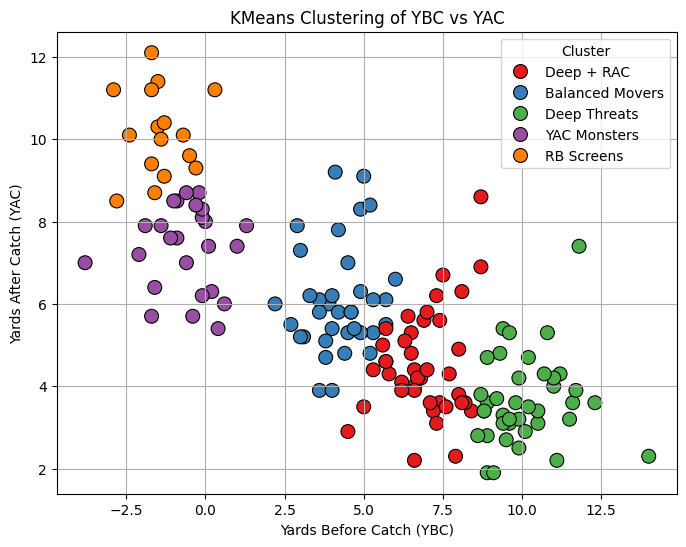

In [ ]:
labels = {
  0: 'RB Screens',
  1: 'Deep + RAC',
  2: 'Deep Threats',
  3: 'Balanced Movers',
  4: 'YAC Monsters'
}
df['cluster_label'] = df['cluster'].map(labels)

plt.figure(figsize=(8, 6))
sns.scatterplot(
  data=df,
  x='YBC_R',
  y='YAC_R',
  hue='cluster_label',
  palette='Set1',
  s=100,
  edgecolor='k',
  legend='full'
)
plt.title('KMeans Clustering of YBC vs YAC')
plt.xlabel('Yards Before Catch (YBC)')
plt.ylabel('Yards After Catch (YAC)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

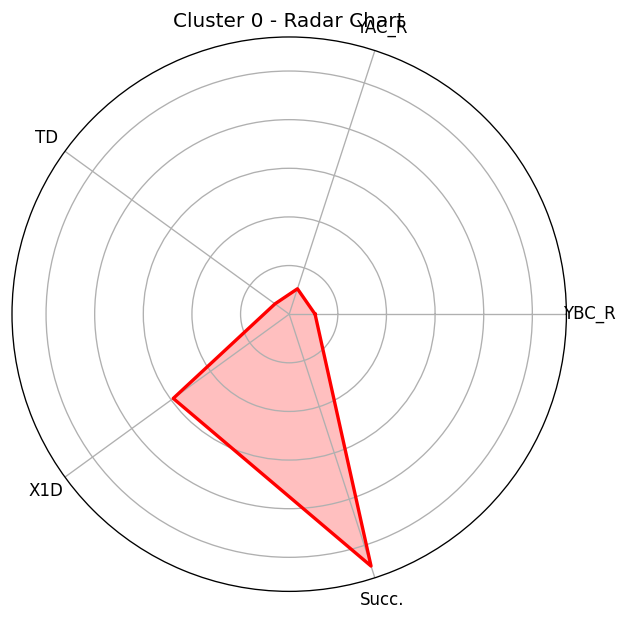

In [ ]:
from math import pi
import pandas as pd
import numpy as np

# Example for Cluster 0 (adjust for other clusters)
cluster0_mean = cluster0_sorted[['YBC_R', 'YAC_R', 'TD', 'X1D', 'Succ.']].mean().round(2)
categories = list(cluster0_mean.index)
values = cluster0_mean.values

# Create a radar chart
fig, ax = plt.subplots(figsize=(8, 6), dpi=120, subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

ax.set_yticklabels([])  # Remove radial labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title('Cluster 0 - Radar Chart')
plt.show()


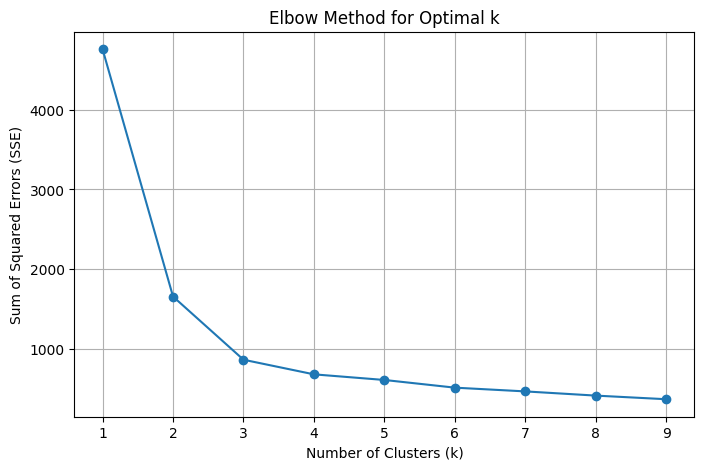

In [ ]:
r = range(1, 10)
sse = []

for k in r:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[['YBC_R', 'YAC_R']])
    sse.append(km.inertia_)  # Sum of Squared Errors (Inertia)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(r, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.xticks(r)
plt.grid(True)
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
df.dropna(subset=numeric_cols, inplace=True)

[7.07422572e+00 3.52399755e+00 1.32093826e+00 1.20212310e+00
 8.31117133e-01 7.23343825e-01 4.89433929e-01 3.60037526e-01
 2.21605217e-01 1.79283844e-01 9.39544341e-02 3.34124565e-02
 2.66776516e-02 1.60602402e-02 6.35322251e-03 3.27138270e-32]


<ipython-input-12-4468cc11503a>:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


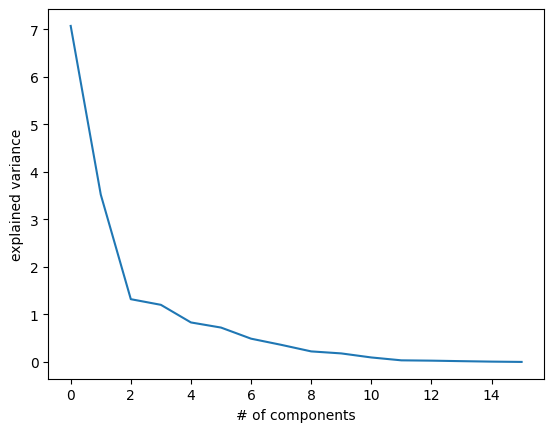

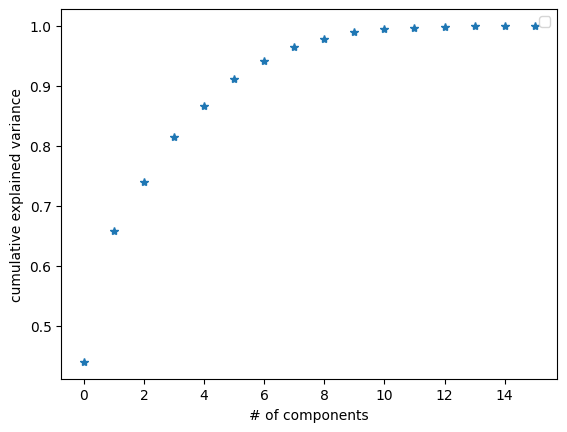

In [ ]:
from sklearn.preprocessing import StandardScaler
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any NaN values in numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df.dropna(subset=numeric_cols, inplace=True)

# Now proceed with scaling and PCA
X = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ... (rest of your code)

pca = PCA()
pca.fit(X_scaled)
#print(pca.components_)
print(pca.explained_variance_)

plt.plot(pca.explained_variance_)
plt.xlabel("# of components")
plt.ylabel("explained variance")

cum_sum_eigenvalues = np.cumsum(pca.explained_variance_/np.sum(pca.explained_variance_))

plt.figure()
plt.plot(cum_sum_eigenvalues,"*")
plt.xlabel("# of components")
plt.ylabel("cumulative explained variance")
plt.legend()

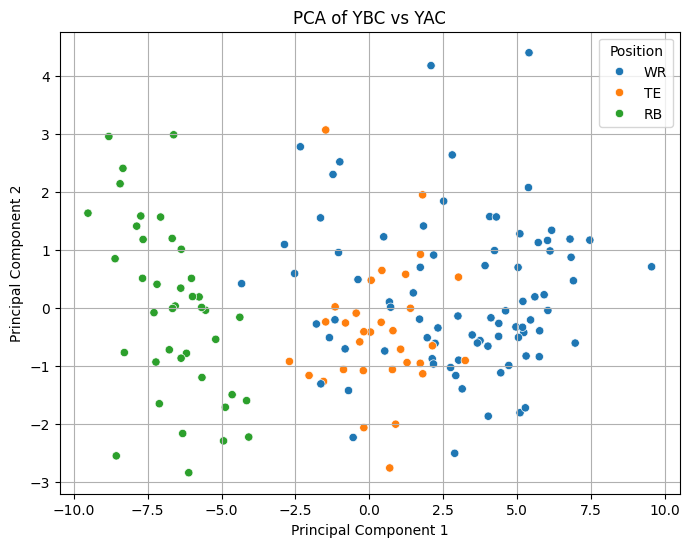

Explained Variance Ratio: [0.92455784 0.07544216]
Total Explained Variance: 1.0


In [ ]:
pca = PCA(n_components=2)
pca.fit(df[['YBC_R', 'YAC_R']])
df[['PC1', 'PC2']] = pca.fit_transform(df[['YBC_R', 'YAC_R']])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Pos')
plt.title('PCA of YBC vs YAC')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Position')
plt.grid(True)
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))

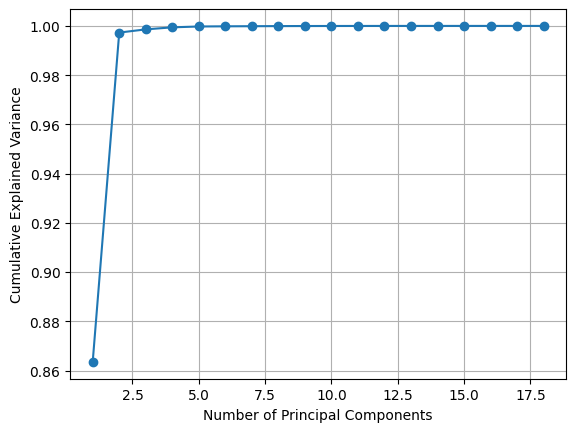

In [ ]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any NaN values in numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df.dropna(subset=numeric_cols, inplace=True)

pca = PCA()
components = pca.fit_transform(df[numeric_cols])
explained = pca.explained_variance_ratio_

plt.plot(range(1, len(explained)+1), explained.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

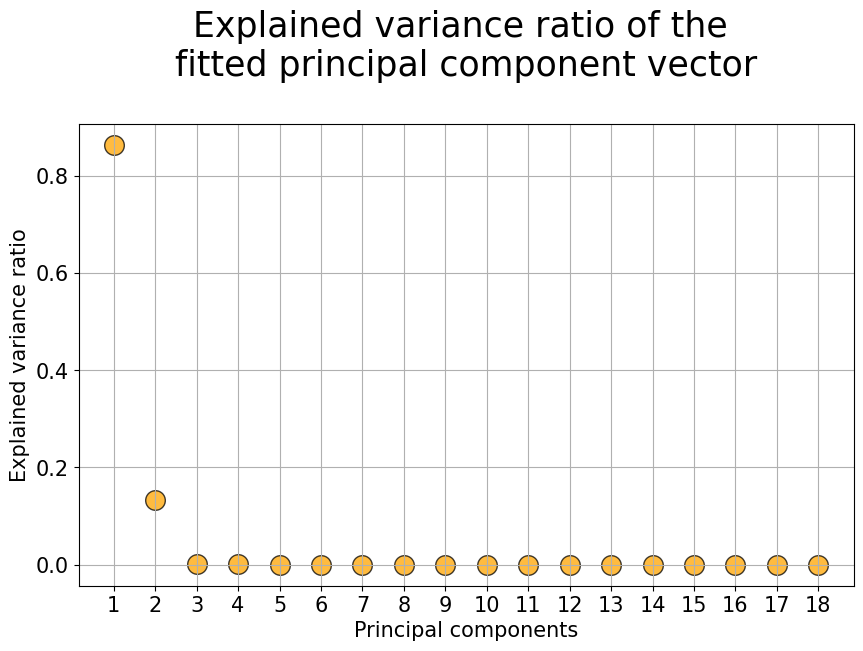

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(x=[i+1 for i in range(len(pca.explained_variance_ratio_))],
            y=pca.explained_variance_ratio_,
           s=200, alpha=0.75,c='orange',edgecolor='k')
plt.grid(True)
plt.title("Explained variance ratio of the \nfitted principal component vector\n",fontsize=25)
plt.xlabel("Principal components",fontsize=15)
plt.xticks([i+1 for i in range(len(pca.explained_variance_ratio_))],fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Explained variance ratio",fontsize=15)
plt.show()

In [ ]:
# keep the first two principal components of the data
pca = PCA(n_components=2)
# fit PCA model to beast cancer data
pca.fit(df[['YBC_R', 'YAC_R']])

# transform data onto the first two principal components
X_pca = pca.transform(df[['YBC_R', 'YAC_R']])
print("Original shape: {}".format(str(df[['YBC_R', 'YAC_R']].shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

Original shape: (157, 2)
Reduced shape: (157, 2)


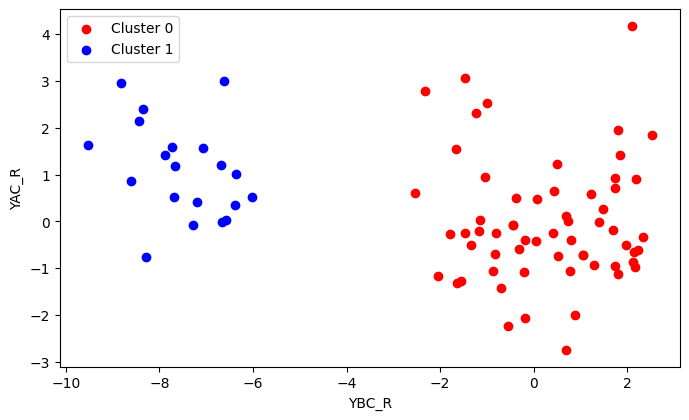

In [ ]:
plt.figure(figsize=(8, 8))
# Assuming 'cluster' column represents your target
plt.scatter(X_pca[df['cluster']==0, 0], X_pca[df['cluster']==0, 1], c="red", label='Cluster 0') # Assuming 'cluster' represents the target
plt.scatter(X_pca[df['cluster']==1, 0], X_pca[df['cluster']==1, 1], c="blue", label='Cluster 1') # Assuming 'cluster' represents the target

plt.legend(loc="best")  # Use the labels defined in the scatter plots
plt.gca().set_aspect("equal")
plt.xlabel("YBC_R")
plt.ylabel("YAC_R")
plt.show() # Add plt.show() to display the plot

In [ ]:
print("PCA component shape: {}".format(pca.components_.shape))

PCA component shape: (2, 2)


In [ ]:
print("PCA explained variance:\n{}".format(pca.explained_variance_))

PCA explained variance:
[21.46517901  1.75151787]


Neural Network

In [ ]:
!pip install scikit-learn mglearn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.8 MB/s eta 0:00:00


In [ ]:
# Assuming 'cluster' is your target variable and 'YBC_R', 'YAC_R' are features
X = df[['YBC_R', 'YAC_R', 'Succ.', 'TD']]
y = df['cluster']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(solver='adam', random_state=0, max_iter=10000).fit(X_train, y_train)
print("Training set score: %f" % mlp.score(X_train, y_train))
print("Test set score: %f" % mlp.score(X_test, y_test))

Training set score: 0.982906
Test set score: 0.975000


Best score: 0.947368
Best params: {'learning_rate': 0.0001, 'hidden_layer_sizes': (10,)}
val set score: 0.947368
Training set score: 0.946429
Best score: 1.000000
Best params: {'learning_rate': 0.001, 'hidden_layer_sizes': (10,)}
val set score: 1.000000
Training set score: 1.000000
Test set score: 1.000000


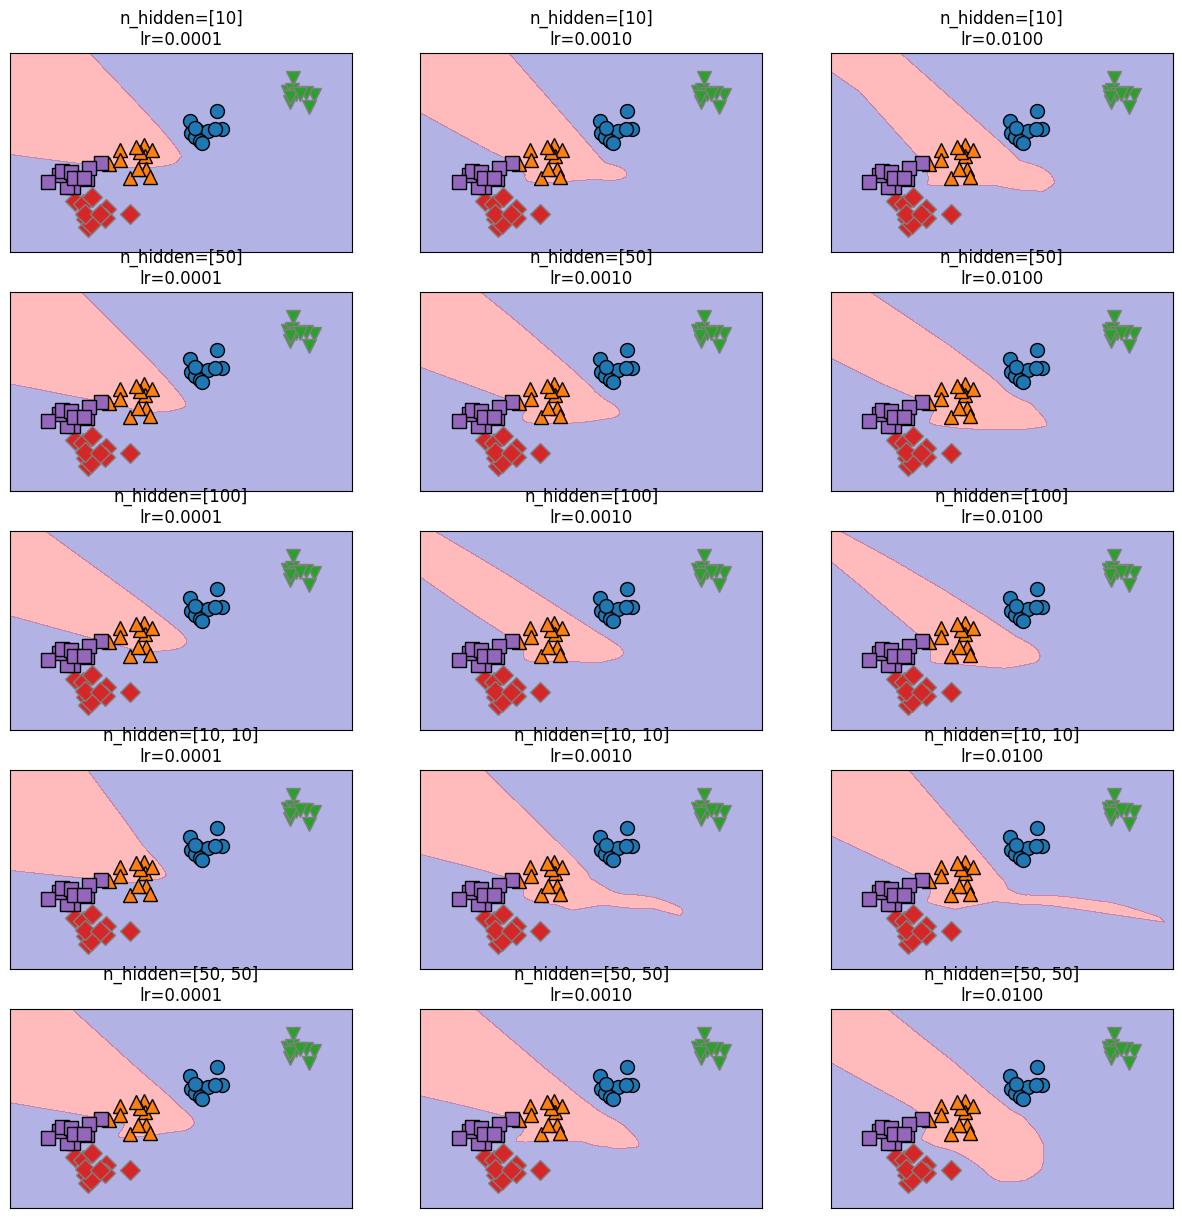

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.datasets import make_blobs
import mglearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generate data
X, y = make_blobs(n_samples=100, centers=5, random_state=3)

# Split into training, validation, and test sets
X_train_, X_test, y_train_, y_test = train_test_split(X, y, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_, y_train_, stratify=y_train_, random_state=42)

# Grid search
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
learning_rates = [0.0001, 0.001, 0.01, 0.1]  # Expanded range
hidden_layer_sizes = [(10,), (50,), (100,), (10, 10), (50, 50), (100, 100), (50, 25, 10)] # More options
best_score = 0
best_params = {}

for ax, hls in zip(axes, hidden_layer_sizes):
    for axx, lr in zip(ax, learning_rates):
        mlp = MLPClassifier(solver='adam', random_state=0, hidden_layer_sizes=hls, learning_rate_init=lr, max_iter=5000)
        mlp.fit(X_train, y_train)

        mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=axx)
        mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=axx)
        if len(hls) > 1:
            axx.set_title("n_hidden=[{}, {}]\nlr={:.4f}".format(hls[0], hls[1], lr))
        else:
            axx.set_title("n_hidden=[{}]\nlr={:.4f}".format(hls[0], lr))

        score = mlp.score(X_val, y_val)
        if score > best_score:
            best_score = score
            best_params = {'learning_rate': lr, 'hidden_layer_sizes': hls}
            print("Best score: %f" % best_score)
            print("Best params: %s" % best_params)
            print("val set score: %f" % mlp.score(X_val, y_val))
            print("Training set score: %f" % mlp.score(X_train, y_train))

# Train a model with the best parameters
mlp = MLPClassifier(solver='adam', random_state=0, hidden_layer_sizes=best_params['hidden_layer_sizes'], learning_rate_init=best_params['learning_rate'], max_iter=5000)
mlp.fit(X_train_, y_train_)

print("Test set score: %f" % mlp.score(X_test, y_test))

plt.show()

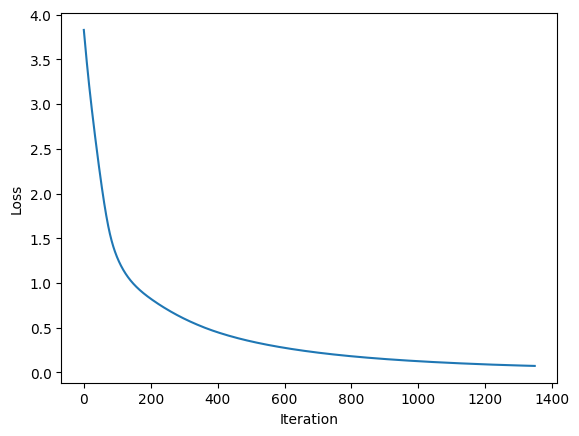

In [ ]:
#plot loss curve
plt.figure()
plt.plot(mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## Data loading

### Subtask:
Load the dataset "Receiving2024Season.csv" into a pandas DataFrame.


**Reasoning**:
Load the dataset "Receiving2024Season.csv" into a pandas DataFrame and display its first few rows and shape.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('Receiving2024Season.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'Receiving2024Season.csv' not found.")
    df = None
except Exception as e:
    print(f"An error occurred: {e}")
    df = None

,Unnamed: 0,Player,Age,Pos,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,BrkTkl,Succ.,TD,YBC_R,YAC_R,Rec_Brk
0,1,Ja'Marr Chase,24,WR,175,127,1708,75,921,787,8.7,11,62.3,17,7.3,6.2,11.5
1,2,Amon-Ra St. Brown,25,WR,141,115,1263,73,851,412,7.7,3,70.2,12,7.4,3.6,38.3
2,3,Brock Bowers,22,TE,153,112,1194,61,598,596,6.1,6,60.8,5,5.3,5.3,18.7
3,4,Trey McBride,25,TE,147,111,1146,63,633,513,6.1,5,63.3,2,5.7,4.6,22.2
4,5,Malik Nabers,21,WR,170,109,1204,55,742,462,9.1,8,51.2,7,6.8,4.2,13.6


(554, 17)


## Data cleaning

### Subtask:
Clean the loaded data.


**Reasoning**:
Clean the data by handling missing values, outliers, duplicates, and data type conversions.



In [ ]:
# Handle missing values
df_cleaned = df.copy()
for col in df_cleaned.columns:
    if df_cleaned[col].isnull().any():
        if df_cleaned[col].dtype == 'object':
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
        elif df_cleaned[col].dtype in ['int64', 'float64']:
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

# Outlier detection and treatment (using IQR method)
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Handle potential NaN values before clipping
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean()) # Fill NaN with mean
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

# Duplicate removal
df_cleaned.drop_duplicates(inplace=True)

# Data type conversion (Example: Convert 'Age' to integer if it's not already)
if df_cleaned['Age'].dtype != 'int64':
    df_cleaned['Age'] = df_cleaned['Age'].astype('int64')

display(df_cleaned.head())

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,Unnamed: 0,Player,Age,Pos,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,BrkTkl,Succ.,TD,YBC_R,YAC_R,Rec_Brk
0,1,Ja'Marr Chase,24,WR,126.375,86.5,928.875,44.5,585.625,404.375,8.7,5,62.3,7.5,7.3,6.2,11.5
1,2,Amon-Ra St. Brown,25,WR,126.375,86.5,928.875,44.5,585.625,404.375,7.7,3,70.2,7.5,7.4,3.6,38.3
2,3,Brock Bowers,22,TE,126.375,86.5,928.875,44.5,585.625,404.375,6.1,5,60.8,5.0,5.3,5.3,18.7
3,4,Trey McBride,25,TE,126.375,86.5,928.875,44.5,585.625,404.375,6.1,5,63.3,2.0,5.7,4.6,22.2
4,5,Malik Nabers,21,WR,126.375,86.5,928.875,44.5,585.625,404.375,9.1,5,51.2,7.0,6.8,4.2,13.6


## Data exploration

### Subtask:
Explore the cleaned data (df_cleaned) to understand its structure, identify potential relationships between variables, and gain insights into the distribution of key features.


**Reasoning**:
Explore the cleaned data (df_cleaned) by examining its shape, data types, descriptive statistics, and visualizing the distributions of key features.



Shape of df_cleaned: (554, 17)

Data types of df_cleaned:
 Unnamed: 0      int64
Player         object
Age             int64
Pos            object
Tgt           float64
Rec           float64
Yds           float64
X1D           float64
YBC           float64
YAC           float64
ADOT          float64
BrkTkl          int64
Succ.         float64
TD            float64
YBC_R         float64
YAC_R         float64
Rec_Brk       float64
dtype: object

Descriptive statistics:
        Unnamed: 0         Age         Tgt         Rec         Yds         X1D  \
count  554.000000  554.000000  554.000000  554.000000  554.000000  554.000000   
mean   277.500000   26.379061   35.004513   23.358303  252.375451   12.060469   
std    160.070297    2.945680   34.919095   23.685100  274.784112   13.288136   
min      1.000000   20.000000    1.000000    0.000000   -4.000000    0.000000   
25%    139.250000   24.000000    7.000000    4.000000   33.250000    2.000000   
50%    277.500000   26.000000   22.000000

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


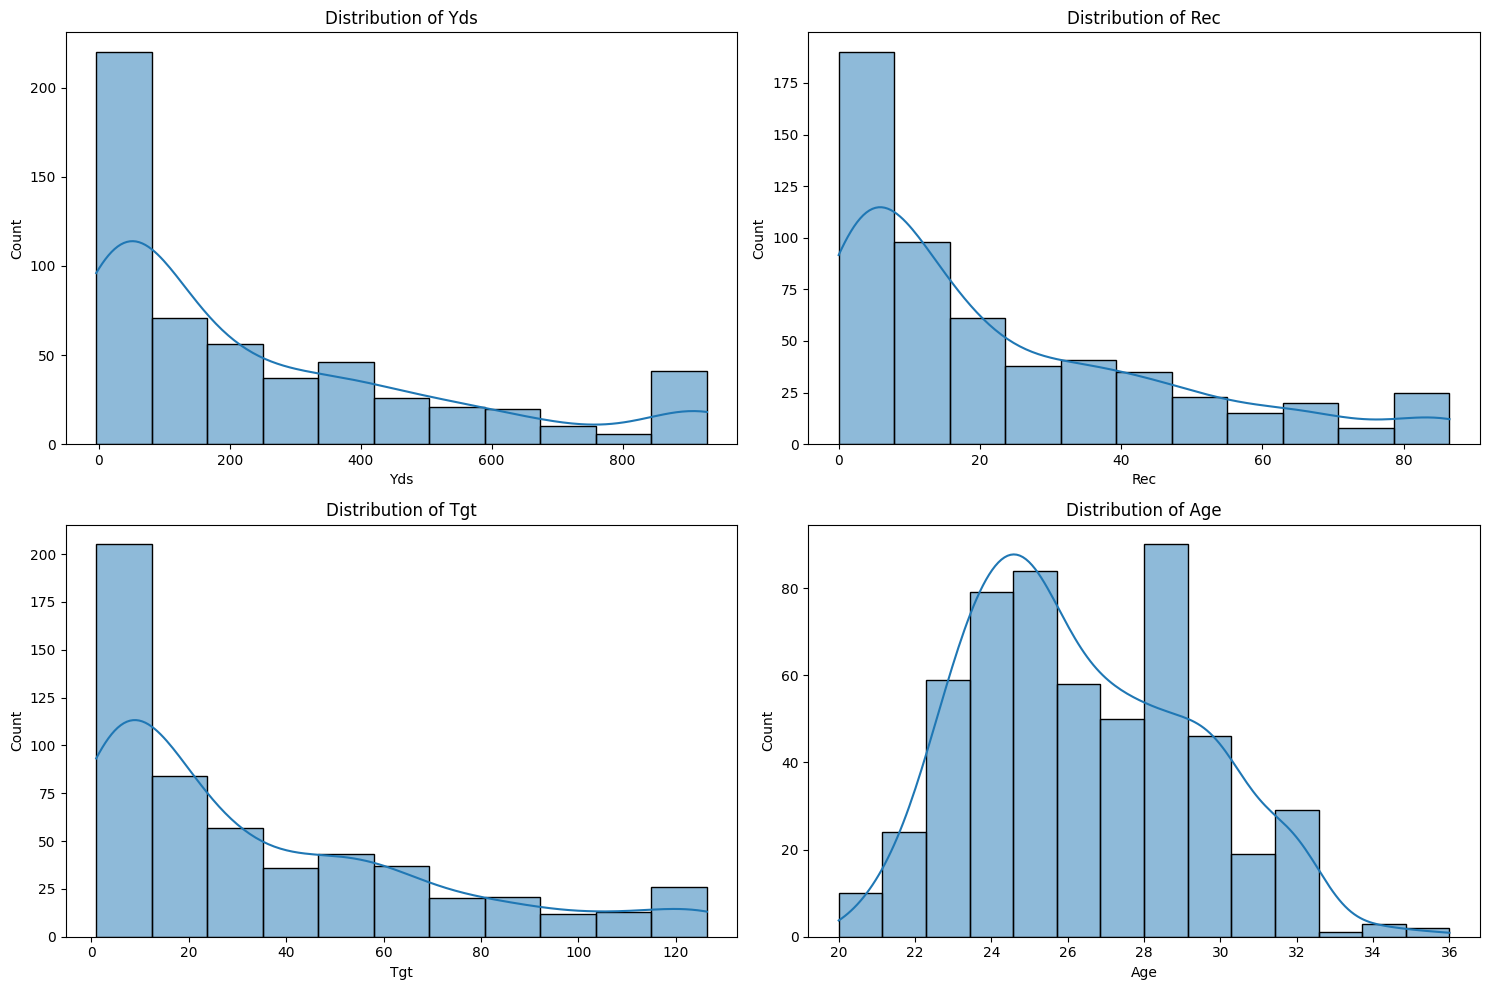

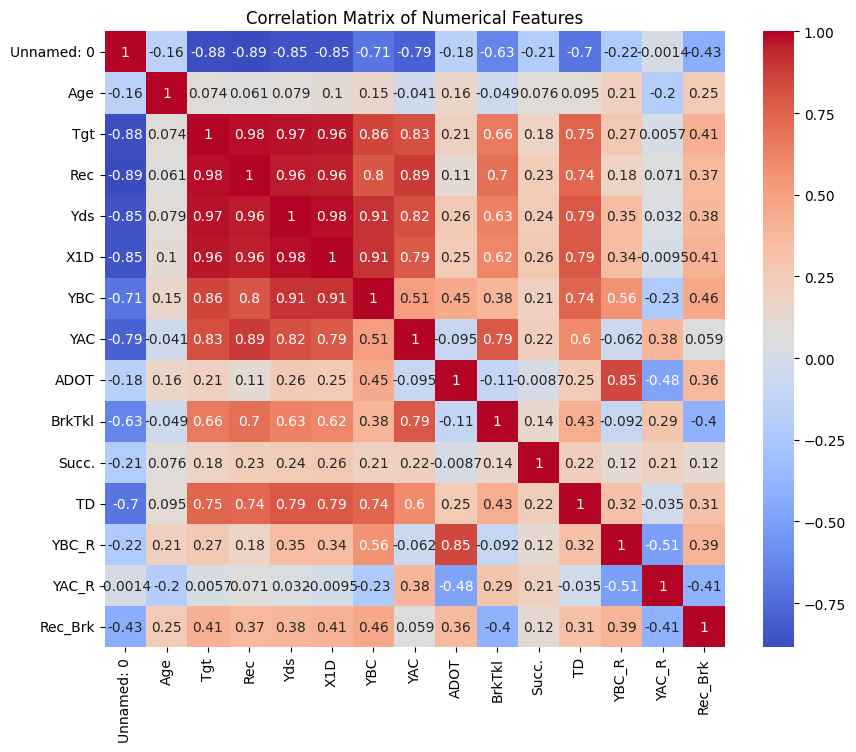


Frequency of Player:
Player
Diontae Johnson             16
Davante Adams                9
Cam Akers                    9
DeAndre Hopkins              9
Marquez Valdes-Scantling     9
                            ..
Parker Washington            1
Sterling Shepard             1
Chris Olave                  1
Foster Moreau                1
Tyjae Spears                 1
Name: count, Length: 465, dtype: int64


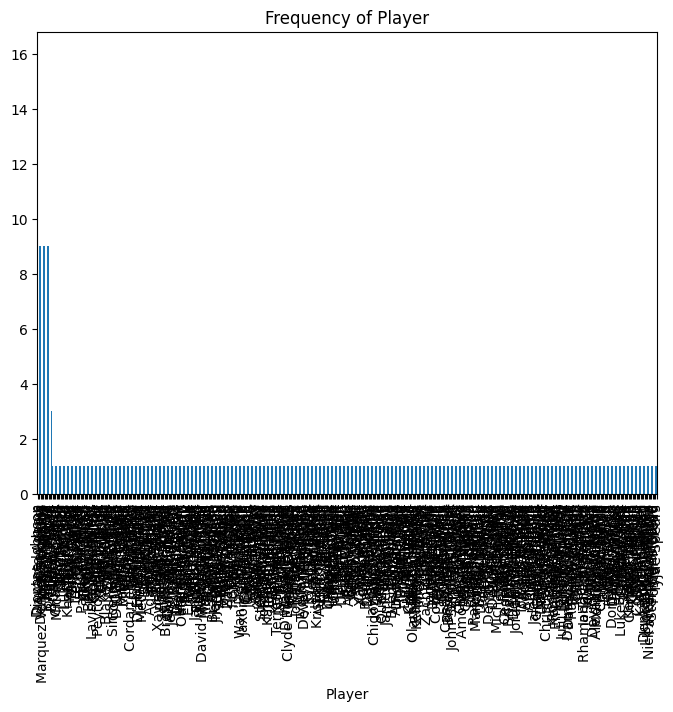

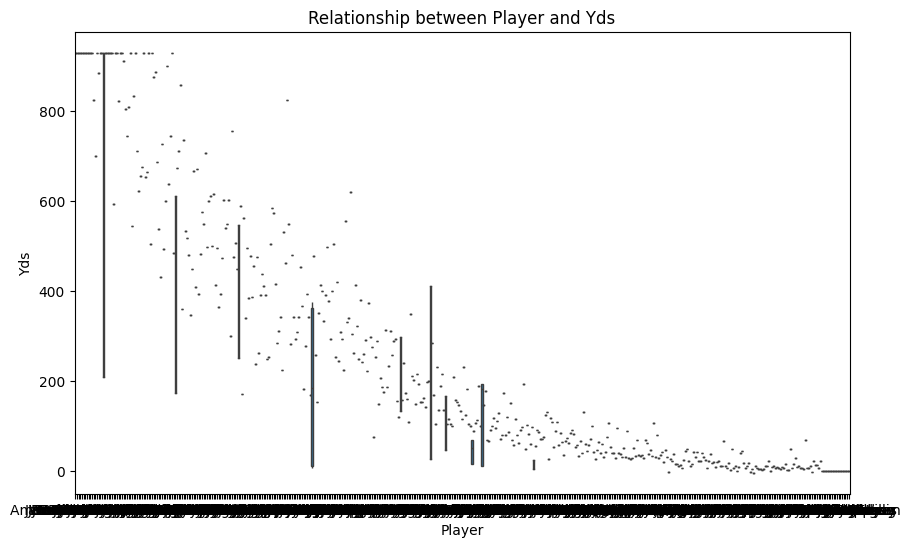


Frequency of Pos:
Pos
WR    296
RB    138
TE    120
Name: count, dtype: int64


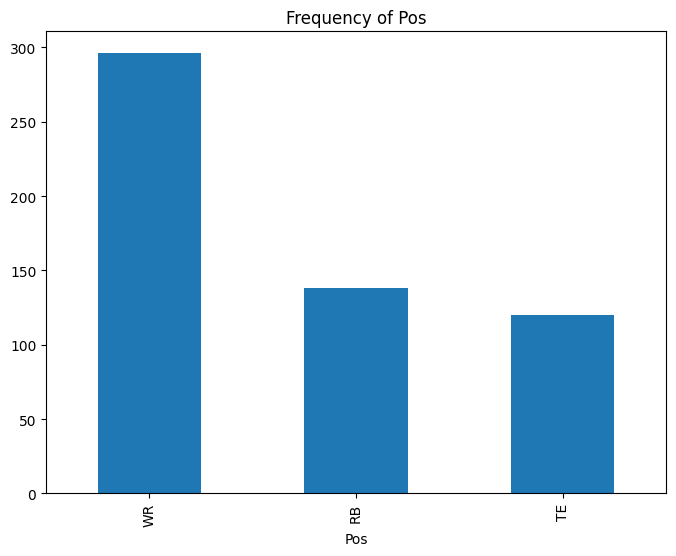

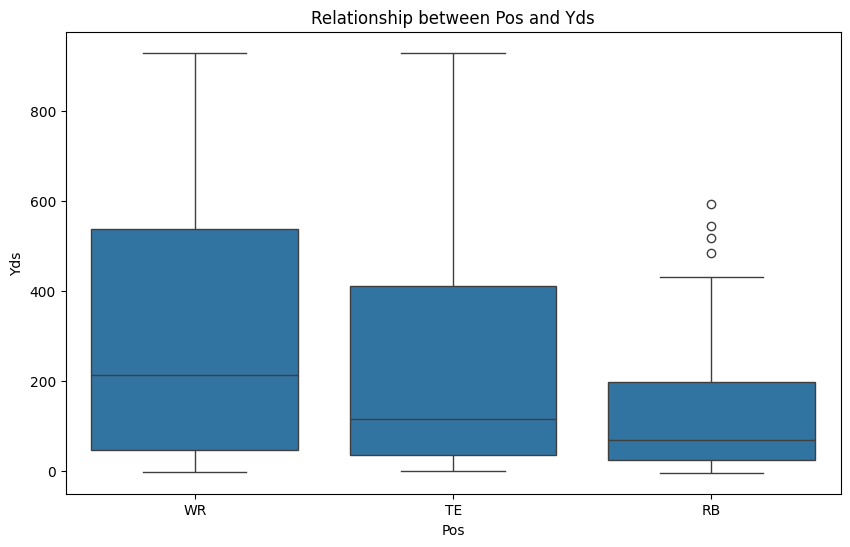

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Examine the shape and data types
print("Shape of df_cleaned:", df_cleaned.shape)
print("\nData types of df_cleaned:\n", df_cleaned.dtypes)

# 2. Descriptive statistics for numerical features
numerical_features = df_cleaned.select_dtypes(include=['number'])
print("\nDescriptive statistics:\n", numerical_features.describe())

# 3. Visualize distributions of key numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Yds', 'Rec', 'Tgt', 'Age']):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


# 4. Investigate relationships between numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 5. Explore categorical features
categorical_features = df_cleaned.select_dtypes(include=['object'])
for col in categorical_features.columns:
    print(f"\nFrequency of {col}:\n{df_cleaned[col].value_counts()}")
    plt.figure(figsize=(8, 6))
    df_cleaned[col].value_counts().plot(kind='bar')
    plt.title(f'Frequency of {col}')
    plt.show()

    # Relationship between categorical and numerical features (example: 'Pos' vs. 'Yds')
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='Yds', data=df_cleaned)
    plt.title(f'Relationship between {col} and Yds')
    plt.show()


## Feature engineering

### Subtask:
Engineer new features from the existing features in `df_cleaned`.


**Reasoning**:
Create interaction, ratio, and polynomial features, and one-hot encode the 'Pos' feature in df_cleaned.



In [ ]:
import numpy as np

# Create interaction features
df_cleaned['Tgt_YAC_Interaction'] = df_cleaned['Tgt'] * df_cleaned['YAC']

# Create ratio features, handling potential division by zero
df_cleaned['Yards_per_Target'] = df_cleaned['Yds'] / df_cleaned['Tgt']
df_cleaned['Yards_per_Target'].replace([np.inf, -np.inf], 0, inplace=True)  # Replace infinite values with 0

df_cleaned['Receptions_per_Target'] = df_cleaned['Rec'] / df_cleaned['Tgt']
df_cleaned['Receptions_per_Target'].replace([np.inf, -np.inf], 0, inplace=True)

# Create polynomial features
df_cleaned['Yds_Squared'] = df_cleaned['Yds'] ** 2
df_cleaned['Rec_Cubed'] = df_cleaned['Rec'] ** 3


# One-hot encode 'Pos'
df_cleaned = pd.get_dummies(df_cleaned, columns=['Pos'], prefix='Pos')

display(df_cleaned.head())

<ipython-input-5-7ad71842a20d>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Yards_per_Target'].replace([np.inf, -np.inf], 0, inplace=True)  # Replace infinite values with 0
<ipython-input-5-7ad71842a20d>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

,Unnamed: 0,Player,Age,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,...,YAC_R,Rec_Brk,Tgt_YAC_Interaction,Yards_per_Target,Receptions_per_Target,Yds_Squared,Rec_Cubed,Pos_RB,Pos_TE,Pos_WR
0,1,Ja'Marr Chase,24,126.375,86.5,928.875,44.5,585.625,404.375,8.7,...,6.2,11.5,51102.890625,7.350148,0.684471,862808.765625,647214.625,False,False,True
1,2,Amon-Ra St. Brown,25,126.375,86.5,928.875,44.5,585.625,404.375,7.7,...,3.6,38.3,51102.890625,7.350148,0.684471,862808.765625,647214.625,False,False,True
2,3,Brock Bowers,22,126.375,86.5,928.875,44.5,585.625,404.375,6.1,...,5.3,18.7,51102.890625,7.350148,0.684471,862808.765625,647214.625,False,True,False
3,4,Trey McBride,25,126.375,86.5,928.875,44.5,585.625,404.375,6.1,...,4.6,22.2,51102.890625,7.350148,0.684471,862808.765625,647214.625,False,True,False
4,5,Malik Nabers,21,126.375,86.5,928.875,44.5,585.625,404.375,9.1,...,4.2,13.6,51102.890625,7.350148,0.684471,862808.765625,647214.625,False,False,True


**Reasoning**:
Fix the warning from the previous code block by not using inplace in the replace function.



## Data preparation

### Subtask:
Prepare the data for modeling by standardizing numerical features and handling the 'Pos' column.


**Reasoning**:
The 'Pos' column is already present in df_cleaned.  I will standardize the numerical features, handling potential errors like NaN or infinite values.  Then, I will proceed with one-hot encoding the 'Pos' column.



In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Identify numerical columns for standardization
# Identify numerical columns for standardization
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns

# Check if 'Unnamed: 0' is in the numerical columns before dropping
if 'Unnamed: 0' in numerical_cols:
    numerical_cols = numerical_cols.drop(['Unnamed: 0'])  #dropping the index column

# Standardize numerical features
scaler = StandardScaler()

# Handling potential errors during scaling
for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].replace([np.inf, -np.inf], 0)
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

display(df_cleaned.head())

,Unnamed: 0,Player,Age,Tgt,Rec,Yds,X1D,YBC,YAC,ADOT,...,YAC_R,Rec_Brk,Tgt_YAC_Interaction,Yards_per_Target,Receptions_per_Target,Yds_Squared,Rec_Cubed,Pos_RB,Pos_TE,Pos_WR
0,1,Ja'Marr Chase,-0.808374,2.618999,2.668292,2.464156,2.443446,2.452051,2.324103,0.309578,...,0.457210,0.237366,3.489931,0.193068,0.09641,3.034146,3.975885,False,False,True
1,2,Amon-Ra St. Brown,-0.468587,2.618999,2.668292,2.464156,2.443446,2.452051,2.324103,0.146915,...,-0.472815,2.328895,3.489931,0.193068,0.09641,3.034146,3.975885,False,False,True
2,3,Brock Bowers,-1.487948,2.618999,2.668292,2.464156,2.443446,2.452051,2.324103,-0.113347,...,0.135278,0.799270,3.489931,0.193068,0.09641,3.034146,3.975885,False,True,False
3,4,Trey McBride,-0.468587,2.618999,2.668292,2.464156,2.443446,2.452051,2.324103,-0.113347,...,-0.115113,1.072417,3.489931,0.193068,0.09641,3.034146,3.975885,False,True,False
4,5,Malik Nabers,-1.827735,2.618999,2.668292,2.464156,2.443446,2.452051,2.324103,0.374643,...,-0.258194,0.401255,3.489931,0.193068,0.09641,3.034146,3.975885,False,False,True


## Data splitting

### Subtask:
Split the prepared data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets using train_test_split, stratifying by 'Pos_WR'.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_cleaned.drop('Yds', axis=1)
y = df_cleaned['Yds']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_cleaned['Pos_WR']
)

## Data visualization

### Subtask:
Visualize the data using t-SNE.


**Reasoning**:
Visualize the data using t-SNE by fitting and transforming the data and plotting the results.



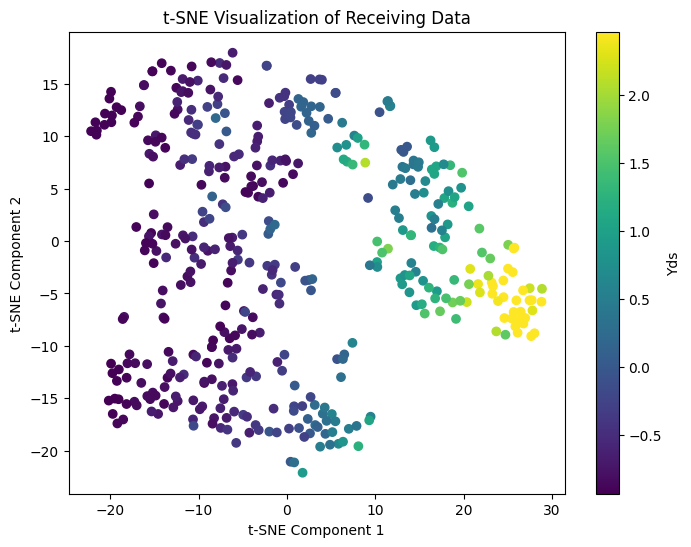

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Check if 'Unnamed: 0' and 'Player' columns exist before dropping
columns_to_drop = ['Player']  # Start with 'Player'
if 'Unnamed: 0' in X_train.columns:
    columns_to_drop.append('Unnamed: 0')

# Drop non-numerical columns before applying t-SNE
X_train_numeric = X_train.drop(columns=columns_to_drop, axis=1)

# Create a t-SNE object
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# Fit and transform the data
tsne_results = tsne.fit_transform(X_train_numeric)

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_train)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Receiving Data")
plt.colorbar(label='Yds')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier  # For classification
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, precision_score, recall_score, f1_score

# Create a k-NN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Define features (X) and target (y) - assuming 'Pos' is the target
X = df_cleaned.drop(['Pos_WR', 'Pos_RB', 'Pos_TE', 'Player'], axis=1)
y = df_cleaned['Pos_WR']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the model to the training data
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # adjust 'average' as needed
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.6576576576576577
Precision: 0.657151465847118
Recall: 0.6576576576576577
F1-score: 0.6554602660593444


In [ ]:
from sklearn.svm import SVC  # Import SVC for classification
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_cleaned.drop(['Pos_WR', 'Pos_RB', 'Pos_TE', 'Player'], axis=1)
y = df_cleaned['Pos_WR']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_cleaned['Pos_WR']
)

# Create an SVR model with an RBF kernel
svm_model = SVC(kernel='rbf')

# Fit the model to the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # adjust 'average' as needed
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy (SVM): {accuracy}")
print(f"Precision (SVM): {precision}")
print(f"Recall (SVM): {recall}")
print(f"F1-score (SVM): {f1}")

Accuracy (SVM): 0.6126126126126126
Precision (SVM): 0.622050622050622
Recall (SVM): 0.6126126126126126
F1-score (SVM): 0.6112273996873753


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Assuming df_cleaned is your DataFrame after data cleaning and feature engineering

# Define features (X) and target (y)
X = df_cleaned.drop(['Yds', 'Player'], axis=1)  # Drop 'Player' column
y = df_cleaned['Yds']

# Discretize the target variable 'Yds' into bins
y_binned = pd.cut(y, bins=5, labels=False)

# Split data into training and testing sets using the binned target
X_train, X_test, y_train_binned, y_test_binned = train_test_split(
    X, y_binned, test_size=0.2, random_state=42, stratify=df_cleaned['Pos_WR']
)

# Create and fit the Gaussian Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train_binned)

# Make predictions and evaluate
y_pred_binned = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_binned)
precision = precision_score(y_test, y_pred_binned, average='weighted') # adjust 'average' as needed
recall = recall_score(y_test, y_pred_binned, average='weighted')
f1 = f1_score(y_test, y_pred_binned, average='weighted')

print(f"Accuracy (Naive Bayes): {accuracy}")
print(f"Precision (Naive Bayes): {precision}")
print(f"Recall (Naive Bayes): {recall}")
print(f"F1-score (Naive Bayes): {f1}")

Accuracy (Naive Bayes): 0.4144144144144144
Precision (Naive Bayes): 0.526026026026026
Recall (Naive Bayes): 0.4144144144144144
F1-score (Naive Bayes): 0.42952130874836186


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Assuming df_cleaned is your DataFrame after data cleaning and feature engineering

# 1. Create a binary target variable
df_cleaned['above_median_yds'] = (df_cleaned['Yds'] > df_cleaned['Yds'].median()).astype(int)

# 2. Define features (X) and target (y)
X = df_cleaned.drop(['Yds', 'Player', 'above_median_yds'], axis=1)  # Drop irrelevant columns
y = df_cleaned['above_median_yds']

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Standardize features (important for gradient descent)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Gradient Descent Implementation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for _ in range(iterations):
        linear_model = np.dot(X, weights) + bias
        predictions = sigmoid(linear_model)

        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)

        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias

# 6. Train the model
weights, bias = gradient_descent(X_train, y_train)

# 7. Make predictions
predictions = sigmoid(np.dot(X_test, weights) + bias)
y_pred = (predictions >= 0.5).astype(int)  # Convert probabilities to class labels

# 8. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # adjust 'average' as needed
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy (Logistic Regression with Gradient Descent): {accuracy}")
print(f"Precision (Gradient): {precision}")
print(f"Recall (Gradient): {recall}")
print(f"F1-score (Gradient): {f1}")

Accuracy (Logistic Regression with Gradient Descent): 0.963963963963964
Precision (Gradient): 0.9663663663663663
Recall (Gradient): 0.963963963963964
F1-score (Gradient): 0.9639053497218755


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # Import the Classifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 0.009009009009009009
Root Mean Squared Error (RMSE): 0.0949157995752499
Mean Absolute Error (MAE): 0.009009009009009009
R-squared (R2): 0.9639610389610389


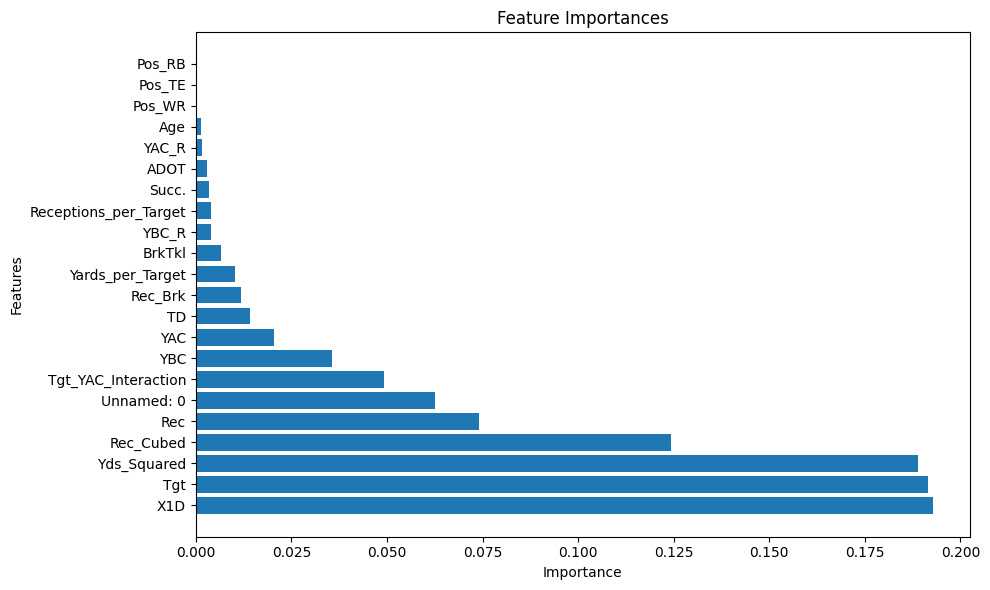

X1D                      0.192816
Tgt                      0.191608
Yds_Squared              0.188979
Rec_Cubed                0.124378
Rec                      0.074151
Unnamed: 0               0.062601
Tgt_YAC_Interaction      0.049131
YBC                      0.035707
YAC                      0.020471
TD                       0.014282
Rec_Brk                  0.011891
Yards_per_Target         0.010144
BrkTkl                   0.006581
YBC_R                    0.003996
Receptions_per_Target    0.003973
Succ.                    0.003384
ADOT                     0.002862
YAC_R                    0.001672
Age                      0.001222
Pos_WR                   0.000113
Pos_TE                   0.000035
Pos_RB                   0.000002
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_classifier.feature_importances_

# Get the feature names from the original DataFrame (before scaling)
feature_names = X.columns  # Assuming X is your original DataFrame before scaling

# Create a Series for better visualization
feature_importances = pd.Series(importances, index=feature_names)

# Sort feature importances in descending order
feature_importances_sorted = feature_importances.sort_values(ascending=False)

# Plot feature importances with flipped axes
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_sorted.index, feature_importances_sorted.values)  # Use barh for horizontal bars
plt.title('Feature Importances')
plt.ylabel('Features')  # Y-axis now shows features
plt.xlabel('Importance')  # X-axis now shows importance
plt.tight_layout()
plt.show()

# Print feature importances
print(feature_importances_sorted)